In [18]:
%pip install pandas
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


# Setup

In [28]:
import pandas as pd
import sys
import logging
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("demo_log.txt"),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger()

FILE_NAME = "laptop_price - dataset.csv"
PRICE_COL = "Price (Euro)"
OS_COL = "OpSys"
STORAGE_COL = "Memory"
RAM_COL = "RAM (GB)"
COMPANY_COL = "Company"

# data loading

In [20]:
try:
    df = pd.read_csv(FILE_NAME)
    initial_count = len(df)
    logger.info("Data loaded")
        
except FileNotFoundError:
    logger.error(f"File {FILE_NAME} not found.")
    sys.exit(1)
except Exception as e:
    logger.error(f"Critical Error: {e}", exc_info=True)
    sys.exit(1)

2026-02-15 21:58:41,980 - INFO - Data loaded


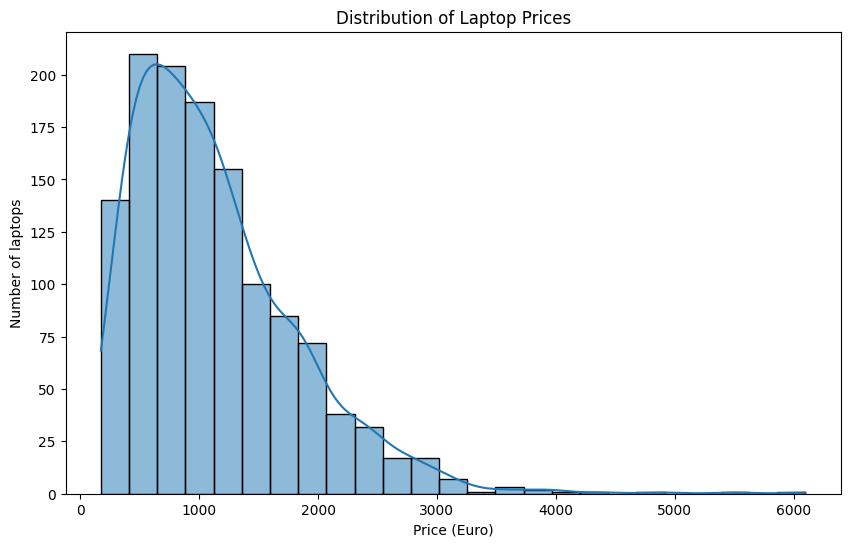

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(df[PRICE_COL], bins=25, kde=True)
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price (Euro)')
plt.ylabel('Number of laptops')
plt.show()

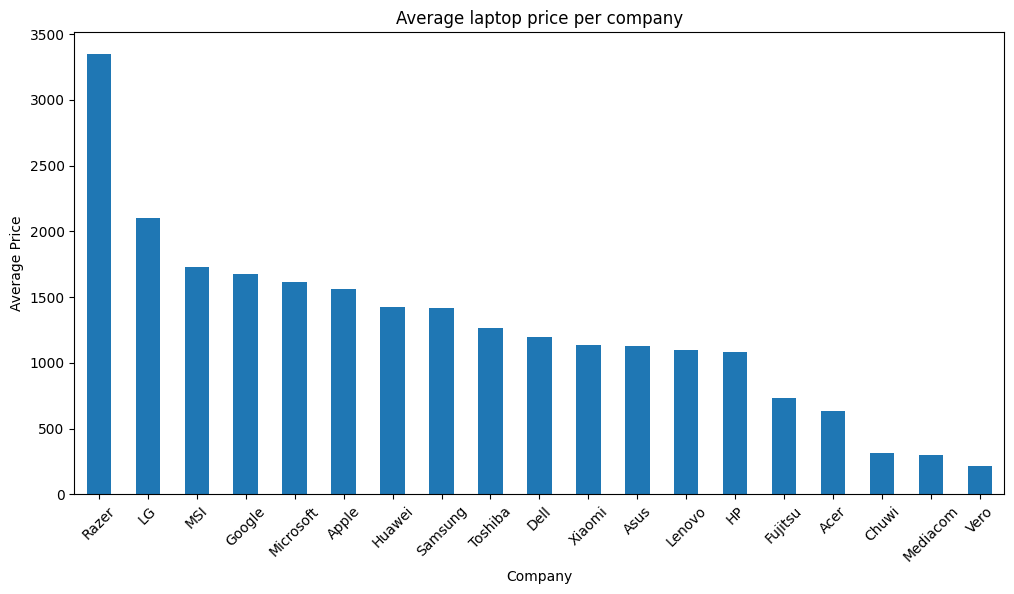

In [29]:
avg_price = df.groupby(COMPANY_COL)[PRICE_COL].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_price.plot(kind='bar')
plt.title('Average laptop price per company')
plt.xlabel('Company')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

In [ ]:
def standardize_categorical_column(
    df: pd.DataFrame, 
    candidate_cols: list[str], 
    category_mapping: dict[str, list[str]], 
    output_col_name: str = 'standardized_col'
) -> pd.DataFrame | None:
    """
    Generalizes column standardization by accepting dynamic column names and mapping rules.

    Args:
        df (pd.DataFrame): The input DataFrame.
        candidate_cols (list[str]): A list of potential column names to search for (case-insensitive).
        category_mapping (dict[str, list[str]]): A dictionary mapping the desired output value to a list of possible input variations.
    Returns:
        pd.DataFrame: Cleaned DataFrame with the new standardized column, 
                      or None if the target column is not found.
    """
    new_df = df.copy()

    # Identify the target column dynamically
    candidates_lower = {c.lower() for c in candidate_cols}
    
    # Find the first column in the DF that matches one of the candidates
    target_col = next((col for col in df.columns if col.lower() in candidates_lower), None)

    if not target_col:
        logger.error(f"None of the candidate columns {candidate_cols} found in the dataset.")
        return None

    logger.info(f"Found target column: '{target_col}'")

    # Prepare the lookup dictionary
    lookup_map = {}
    for standard_val, variations in category_mapping.items():
        for var in variations:
            # Convert variation to string and lowercase to ensure robust matching
            lookup_map[str(var).lower().strip()] = standard_val

    raw_series = new_df[target_col].astype(str).str.strip().str.lower()
    new_df[output_col_name] = raw_series.map(lookup_map)

    # Log results
    counts = new_df[output_col_name].value_counts()
    logger.info(f"Standardization complete for '{output_col_name}'. Counts: {counts.to_dict()}")

    # Drop rows where the value could not be standardized
    new_df = new_df.dropna(subset=[output_col_name])

    return new_df
